Accuracy: 0.6666666666666666
              precision    recall  f1-score   support

          no       0.50      1.00      0.67         1
         yes       1.00      0.50      0.67         2

    accuracy                           0.67         3
   macro avg       0.75      0.75      0.67         3
weighted avg       0.83      0.67      0.67         3

Saved decision tree for weather dataset.


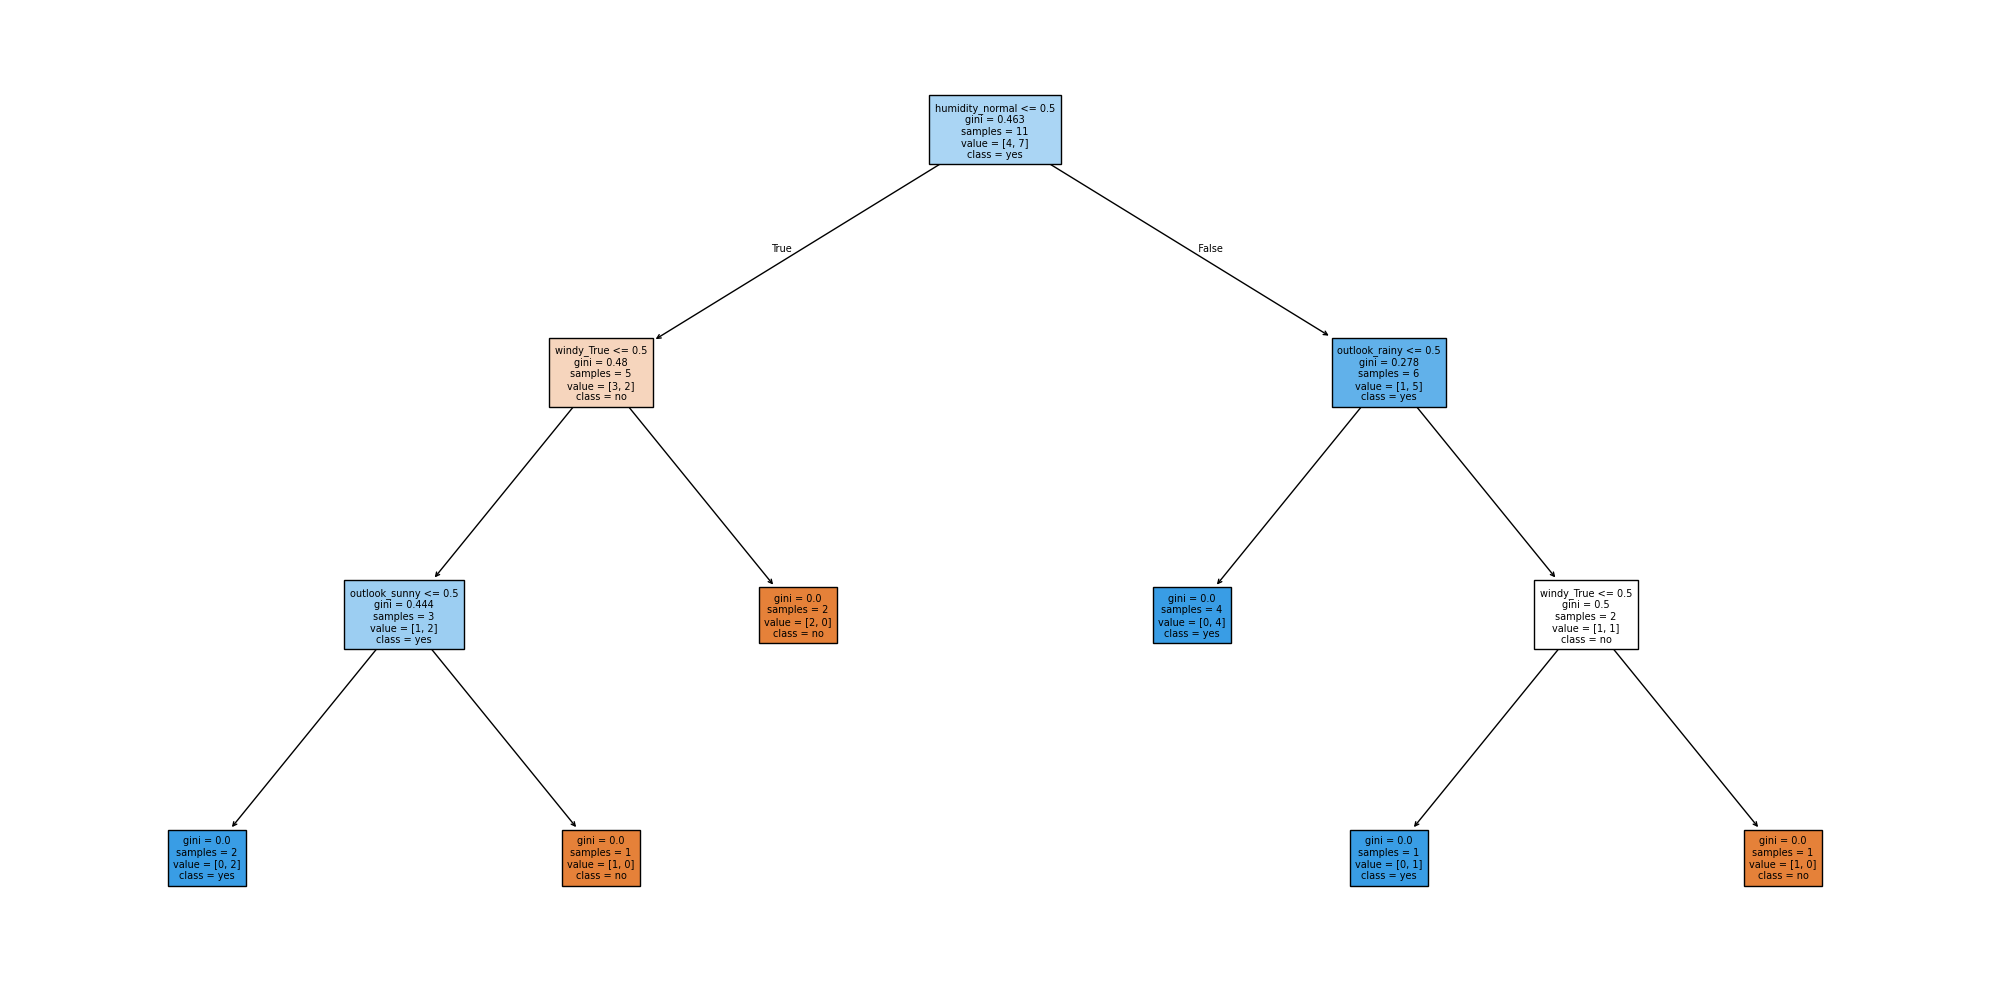

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

df = pd.read_csv('weather_play_dataset (1).csv')

# Handle missing values (if any) for the weather dataset
for col in df.columns:
    if pd.api.types.is_numeric_dtype(df[col]):
        df[col] = df[col].fillna(df[col].median())
    else:
        # For categorical columns, fill with mode, ensuring 'play' (target) is handled correctly
        if col != 'play': # Don't fill missing values for target if it's categorical, drop rows instead if needed
            df[col] = df[col].fillna(df[col].mode()[0])

# One-hot encode categorical features relevant to the weather dataset
df_encoded = pd.get_dummies(df, columns=[
    'outlook', 'temp', 'humidity', 'windy'
], drop_first=True)

# Define features (X) and target (y) for the weather dataset
X = df_encoded.drop(columns=['Day', 'play'])
y = df_encoded['play']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = DecisionTreeClassifier(max_depth=4, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

plt.figure(figsize=(20, 10))
# Update class_names to reflect 'play' column values: 'no' and 'yes'
plot_tree(model, feature_names=X.columns, class_names=['no', 'yes'], filled=True, fontsize=7)
plt.tight_layout()
plt.savefig('decision_tree_weather.png', dpi=150)
print("Saved decision tree for weather dataset.")
